# V18: MDS on Recipe Vectors vs Free Sorting Reference

Applies the same MDS + threshold clustering pipeline from V17 (free sorting) to the **ingredient-based recipe vectors** from V9.  
Answers: *does our threshold-weighted feature space produce a map that resembles the panelist free sorting result?*

**Models compared:**
- M1: OT1 Grandfamilien (no threshold)
- M2: OT1 Grandfamilien + threshold weighting  
- M3: OT1+OT2+OT3 weighted (no threshold)
- M4: OT1+OT2+OT3 weighted + threshold

## Algorithm Reference

| Algorithm | Type | How it works (short) |
|---|---|---|
| **k-Means** | Centroid partition | Iteratively assigns each recipe to the nearest centroid and recomputes centroids until convergence. Minimises total within-cluster variance (Euclidean). k is fixed. |
| **k-Medoids (PAM)** | Medoid partition | Like k-Means but centres are actual data points (*medoids*). More robust to outliers; operates on any distance matrix — here the precomputed cosine distance. |
| **Ward Linkage** | Hierarchical | Builds a merge tree (dendrogram) by always joining the pair of clusters whose merger causes the smallest increase in total within-cluster variance. A cut at distance *t* gives *k* clusters. |
| **DBSCAN** | Density-based | Groups recipes within distance ε of at least `min_samples` neighbours into a cluster. Points that never reach that density threshold become *noise* (resolved here to the nearest cluster). *k* is data-driven. |
| **HDBSCAN** | Hierarchical density | Builds a full hierarchy of DBSCAN solutions across all ε values and extracts the most stable clusters. More robust than DBSCAN when cluster densities vary. |
| **GMM** | Probabilistic | Models data as a mixture of *k* multivariate Gaussians. Each recipe has a soft probability of belonging to each component; the hard label is the highest-probability component. |
| **Spectral Clustering** | Graph-based | Builds a similarity graph (cosine similarity as affinity), computes the Laplacian eigenvectors, then applies k-Means in that low-dimensional embedding. Finds non-convex clusters invisible to k-Means. |
| **Fuzzy c-Means** | Soft partition | Each recipe belongs to *all* k clusters simultaneously with a membership degree (degrees sum to 1). Minimises a weighted within-cluster distance; the fuzziness exponent *m* controls how soft the boundaries are. Hard labels are derived by argmax. |
| **SOM** | Topological map | Trains a 2-D node grid on the recipe vectors via competitive learning: the winning node and its neighbours update towards each input. Recipes are assigned to their closest node; node groups are mapped to *k* clusters via k-Means on the node weights. |
| **DEC (simplified)** | Deep / embedding | Encodes recipes into a compact space (PCA here; a neural autoencoder in the full method), initialises centres with k-Means, then iteratively sharpens soft assignments using a Student-*t* kernel and a KL-divergence target distribution (Xie et al., ICML 2016). |

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize
import openpyxl
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLUSTER_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#A8DADC', '#6A0572', '#264653',
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load Ingredient Data (identical to V9)

In [2]:
DATA_PATH   = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH = '../data/gold/ignone_substances.csv'
CAS_PATH    = '../data/gold/CAS Nummern.csv'

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0

per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])

recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Recipes: {len(recipes)},  sample: {recipes[:4]}')

Recipes: 24,  sample: ['187.796P', '185.028', '185.507P', '187.894P']


## 2. Load Free Sorting Data (from V17)

In [3]:
EXCEL_PATH = Path('../free_sorting/Auswertung Best Of XLStat Erdbeere.xlsm')
wb = openpyxl.load_workbook(EXCEL_PATH, keep_vba=True, data_only=True)

# Raw grouping matrix — Tabelle1 (7): 25 products x 12 assessors
ws_data = wb['Tabelle1 (7)']
rows_fs = list(ws_data.iter_rows(min_row=1, max_row=26, values_only=True))
fs_products = [r[0] for r in rows_fs[1:] if r[0] is not None]
fs_matrix   = np.array([[r[i] for i in range(1, 13)] for r in rows_fs[1:] if r[0] is not None], dtype=float)

# Co-occurrence → dissimilarity
n_fs = len(fs_products)
co_occ = np.zeros((n_fs, n_fs))
for a in range(12):
    g = fs_matrix[:, a]
    for i in range(n_fs):
        for j in range(n_fs):
            if g[i] == g[j]:
                co_occ[i, j] += 1
fs_diss = 1.0 - co_occ / 12
np.fill_diagonal(fs_diss, 0.0)

# XLStat STATIS consensus coordinates (Dim1, Dim2)
ws_xlstat = wb['Free Sorting7']
xlstat_rows = list(ws_xlstat.iter_rows(min_row=132, max_row=157, values_only=True))
xlstat_products, xlstat_d1, xlstat_d2 = [], [], []
for row in xlstat_rows:
    vals = [v for v in row if v is not None]
    if vals and isinstance(vals[0], str) and vals[0].strip() and isinstance(vals[1], (int, float)):
        xlstat_products.append(vals[0])
        xlstat_d1.append(float(vals[1]))
        xlstat_d2.append(float(vals[2]))
xlstat_coords = np.column_stack([xlstat_d1, xlstat_d2])

# Ward clustering on free sorting dissimilarity → 4 clusters at t=1.2
FS_THRESHOLD = 1.2
Z_fs = linkage(squareform(fs_diss, checks=False), method='ward')
labels_fs = fcluster(Z_fs, t=FS_THRESHOLD, criterion='distance')
labels_fs_xlstat = np.array([labels_fs[fs_products.index(p)] for p in xlstat_products])

print(f'Free sorting products: {n_fs}')
print(f'Free sorting clusters at t={FS_THRESHOLD}: {len(np.unique(labels_fs))}')
print(f'XLStat STATIS coords loaded: {len(xlstat_products)} products')

Free sorting products: 25
Free sorting clusters at t=1.2: 4
XLStat STATIS coords loaded: 25 products


## 3. Feature & MDS Helpers

In [4]:
OT1 = 'Odour Type 1 FlavourWheel'
OT2 = 'Odour Type 2 Flavour Wheel'
OT3 = 'Odour Type 3 Flavour Wheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'

def pos_weight(position, n_cols):
    return (n_cols + 1 - position) / n_cols

def thresh_factor(threshold_ppm, fallback=1.0):
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return 1.0 / t if (not np.isnan(t) and t > 0) else fallback
    except (TypeError, ValueError):
        return fallback

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t: all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors(df, recipes, feature_cols_weighted, use_threshold):
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors = np.zeros((len(recipes), len(vocab)), dtype=np.float64)
    for r_idx, recipe in enumerate(recipes):
        for _, row in df[df['Rez.-Nr.'] == recipe].iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0: continue
            t_fac = thresh_factor(row[THRESHOLD_COL]) if use_threshold else 1.0
            ingr_base = qty * t_fac
            for col, col_weight in feature_cols_weighted:
                term = norm_term(row.get(col))
                if term and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * ingr_base
    return vocab, normalize(vectors)

def cosine_dissimilarity(vecs):
    sim = np.clip(vecs @ vecs.T, -1.0, 1.0)
    diss = 1.0 - sim
    np.fill_diagonal(diss, 0.0)
    return diss

def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    if len(x) < 2:
        ax.scatter(x, y, s=80, color=kwargs.get('facecolor', 'gray'), zorder=4)
        return
    cov = np.cov(x, y)
    ev, evec = np.linalg.eigh(cov)
    order = ev.argsort()[::-1]
    ev, evec = ev[order], evec[:, order]
    angle  = np.degrees(np.arctan2(*evec[:, 0][::-1]))
    width  = max(2 * n_std * np.sqrt(abs(ev[0])), 0.001)
    height = max(2 * n_std * np.sqrt(abs(ev[1])), 0.001)
    ax.add_patch(Ellipse(xy=(np.mean(x), np.mean(y)),
                         width=width, height=height, angle=angle, **kwargs))

def mds_plot(ax, coords, names, cluster_labels, title):
    colors = CLUSTER_COLORS[:len(np.unique(cluster_labels))]
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
    ax.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
    for c_idx, cid in enumerate(sorted(np.unique(cluster_labels))):
        mask = cluster_labels == cid
        cx, cy = coords[mask, 0], coords[mask, 1]
        col = colors[c_idx % len(colors)]
        confidence_ellipse(cx, cy, ax, n_std=1.5,
                           facecolor=col, alpha=0.15, edgecolor=col,
                           linewidth=1.3, linestyle='--', zorder=2)
        ax.scatter(cx, cy, color=col, s=60, zorder=4, edgecolors='white', lw=0.7)
        for i, name in enumerate(np.array(names)[mask]):
            ax.annotate(name, (cx[i], cy[i]), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color=col)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('MDS Dim 1', fontsize=8)
    ax.set_ylabel('MDS Dim 2', fontsize=8)
    ax.grid(True, alpha=0.2, lw=0.4)
    ax.tick_params(labelsize=7)

def run_mds(diss, threshold):
    mds = MDS(n_components=2, dissimilarity='precomputed', metric=True,
              n_init=10, max_iter=1000, random_state=42, normalized_stress='auto')
    coords = mds.fit_transform(diss)
    Z = linkage(squareform(diss, checks=False), method='ward')
    labels = fcluster(Z, t=threshold, criterion='distance')
    return coords, Z, labels, mds.stress_

print('Helpers defined.')

Helpers defined.


## 4. All 4 Models — MDS Maps

M1: OT1  stress=0.707  5 clusters
M2: OT1  stress=0.687  6 clusters
M3: OT1+OT2+OT3  stress=0.187  4 clusters
M4: OT1+OT2+OT3  stress=0.221  3 clusters


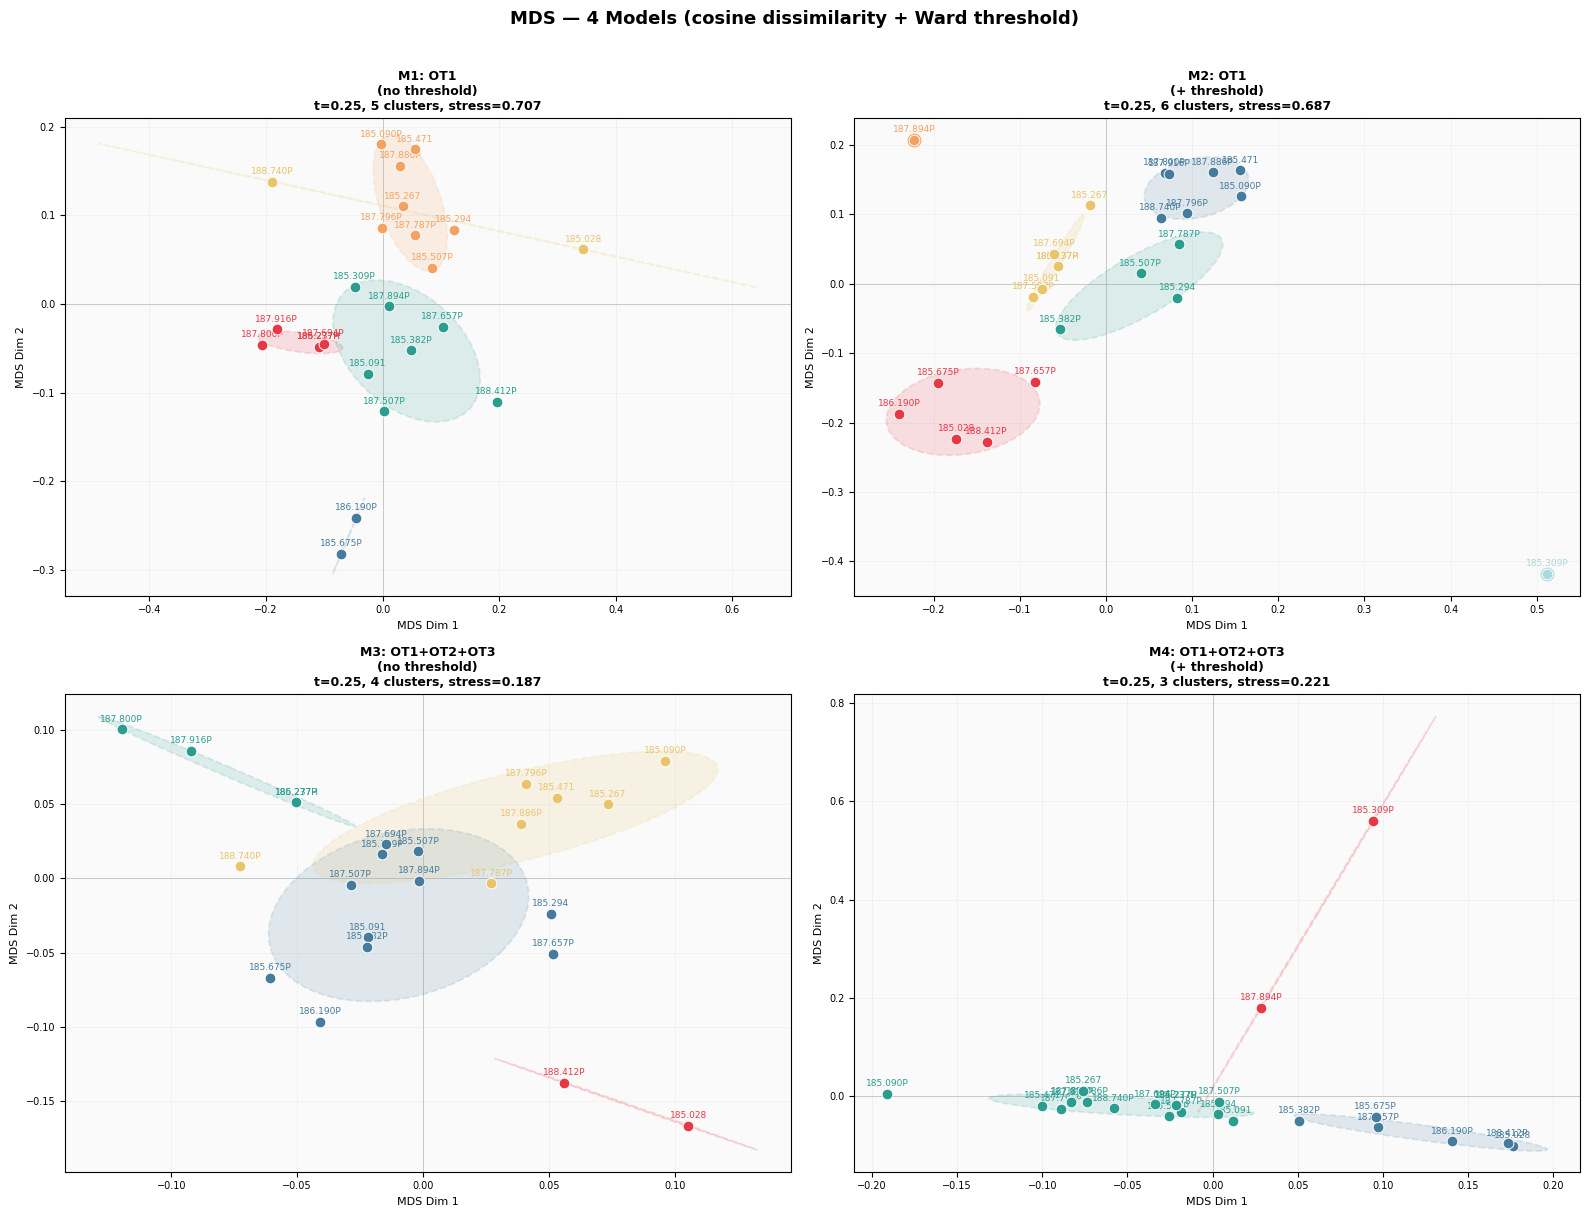

Saved.


In [5]:
MODEL_CONFIGS = [
    {'name': 'M1: OT1\n(no threshold)',         'fcw': [(OT1, 1.0)],                                                              'use_thresh': False},
    {'name': 'M2: OT1\n(+ threshold)',           'fcw': [(OT1, 1.0)],                                                              'use_thresh': True},
    {'name': 'M3: OT1+OT2+OT3\n(no threshold)', 'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': False},
    {'name': 'M4: OT1+OT2+OT3\n(+ threshold)',  'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': True},
]

THRESHOLD = 0.25
all_results = []
for cfg in MODEL_CONFIGS:
    _, vecs = build_recipe_vectors(df, recipes, cfg['fcw'], cfg['use_thresh'])
    diss = cosine_dissimilarity(vecs)
    coords, Z, labels, stress = run_mds(diss, THRESHOLD)
    all_results.append({'name': cfg['name'], 'coords': coords, 'labels': labels,
                        'stress': stress, 'n_clusters': len(np.unique(labels))})
    print(f"{cfg['name'].split(chr(10))[0]}  stress={stress:.3f}  {len(np.unique(labels))} clusters")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, res in zip(axes.flatten(), all_results):
    mds_plot(ax, res['coords'], recipes, res['labels'],
             f"{res['name']}\nt={THRESHOLD}, {res['n_clusters']} clusters, stress={res['stress']:.3f}")
fig.suptitle('MDS — 4 Models (cosine dissimilarity + Ward threshold)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_mds_4models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 5. Threshold Scan for M2 → Find 4-Cluster Threshold

In [6]:
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=True)
diss_m2 = cosine_dissimilarity(vecs_m2)
Z_m2 = linkage(squareform(diss_m2, checks=False), method='ward')

print('Threshold scan for M2 (OT1 + threshold):')
for t in np.arange(0.05, 0.75, 0.05):
    lbl = fcluster(Z_m2, t=t, criterion='distance')
    n_c = len(np.unique(lbl))
    marker = '  <-- 4 clusters' if n_c == 4 else ''
    print(f'  t={t:.2f}  →  {n_c} clusters{marker}')

Threshold scan for M2 (OT1 + threshold):
  t=0.05  →  12 clusters
  t=0.10  →  9 clusters
  t=0.15  →  7 clusters
  t=0.20  →  6 clusters
  t=0.25  →  6 clusters
  t=0.30  →  6 clusters
  t=0.35  →  5 clusters
  t=0.40  →  4 clusters  <-- 4 clusters
  t=0.45  →  4 clusters  <-- 4 clusters
  t=0.50  →  3 clusters
  t=0.55  →  3 clusters
  t=0.60  →  3 clusters
  t=0.65  →  3 clusters
  t=0.70  →  3 clusters


## 6. Force 4 Clusters on M2 — Side-by-Side with Free Sorting

M2: stress=0.687, 4 clusters at t=0.4


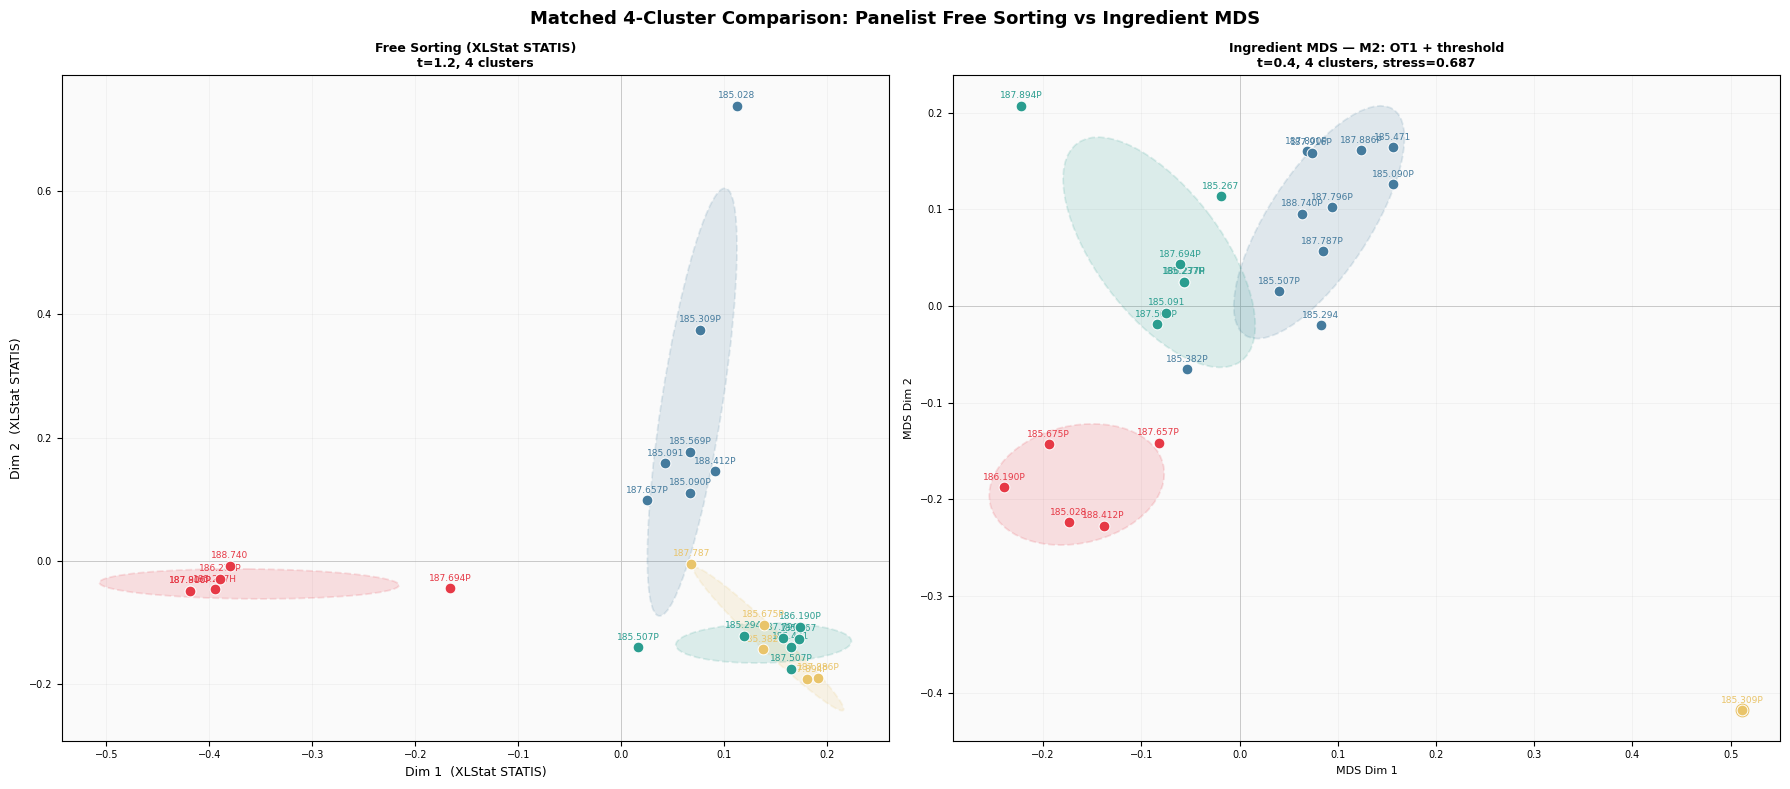

Saved.


In [7]:
ING_THRESHOLD_4 = 0.40  # gives exactly 4 clusters on M2

coords_m2, Z_m2, labels_m2_4, stress_m2 = run_mds(diss_m2, ING_THRESHOLD_4)
n_c_m2 = len(np.unique(labels_m2_4))
print(f'M2: stress={stress_m2:.3f}, {n_c_m2} clusters at t={ING_THRESHOLD_4}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: free sorting (XLStat STATIS coords + Ward 4 clusters)
mds_plot(ax1, xlstat_coords, xlstat_products, labels_fs_xlstat,
         f'Free Sorting (XLStat STATIS)\nt=1.2, 4 clusters')
ax1.set_xlabel('Dim 1  (XLStat STATIS)', fontsize=9)
ax1.set_ylabel('Dim 2  (XLStat STATIS)', fontsize=9)

# Right: ingredient MDS M2 with 4 clusters
mds_plot(ax2, coords_m2, recipes, labels_m2_4,
         f'Ingredient MDS — M2: OT1 + threshold\nt={ING_THRESHOLD_4}, {n_c_m2} clusters, stress={stress_m2:.3f}')

fig.suptitle('Matched 4-Cluster Comparison: Panelist Free Sorting vs Ingredient MDS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_matched_4clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 7. Recipe-by-Recipe Alignment

Use the Hungarian algorithm to find the optimal label mapping between the two 4-cluster solutions, then measure agreement recipe-by-recipe.

In [8]:
# Recipes that appear in BOTH datasets
common = [r for r in recipes if r in fs_products]
print(f'Recipes in both datasets: {len(common)}')

fs_map  = {p: labels_fs[fs_products.index(p)] for p in common}
ing_map = {r: labels_m2_4[recipes.index(r)]   for r in common}

fs_ids  = sorted(set(fs_map.values()))
ing_ids = sorted(set(ing_map.values()))

# Confusion matrix
conf = np.zeros((len(fs_ids), len(ing_ids)), dtype=int)
for r in common:
    conf[fs_ids.index(fs_map[r]), ing_ids.index(ing_map[r])] += 1

print('\nConfusion matrix (rows=Free Sorting, cols=Ingredient):')
print(pd.DataFrame(conf,
                   index=[f'FS-C{c}' for c in fs_ids],
                   columns=[f'ING-C{c}' for c in ing_ids]).to_string())

# Optimal label matching
row_ind, col_ind = linear_sum_assignment(-conf)
fs_to_ing = {fs_ids[r]: ing_ids[c] for r, c in zip(row_ind, col_ind)}
ing_to_fs = {v: k for k, v in fs_to_ing.items()}

n_agree = sum(conf[r, c] for r, c in zip(row_ind, col_ind))
pct     = 100 * n_agree / len(common)
print(f'\nOptimal label mapping: FS→ING = {fs_to_ing}')
print(f'Agreement: {n_agree}/{len(common)} = {pct:.1f}%')

Recipes in both datasets: 22

Confusion matrix (rows=Free Sorting, cols=Ingredient):
       ING-C1  ING-C2  ING-C3  ING-C4
FS-C1       0       2       3       0
FS-C2       3       1       1       1
FS-C3       1       4       2       0
FS-C4       1       2       1       0

Optimal label mapping: FS→ING = {np.int32(1): np.int32(3), np.int32(2): np.int32(1), np.int32(3): np.int32(2), np.int32(4): np.int32(4)}
Agreement: 10/22 = 45.5%


In [9]:
# Per-recipe table
rows_out = []
for r in common:
    fs_c  = fs_map[r]
    ing_c = ing_map[r]
    agree = (fs_to_ing.get(fs_c) == ing_c)
    rows_out.append({'Recipe': r,
                     'Free Sorting Cluster': f'FS-C{fs_c}',
                     'Ingredient Cluster':   f'ING-C{ing_c}',
                     'Match': 'YES' if agree else 'NO'})

df_align = pd.DataFrame(rows_out).sort_values(['Free Sorting Cluster', 'Recipe'])
print(df_align.to_string(index=False))

print('\n--- Per Free Sorting Cluster ---')
for fs_c in fs_ids:
    sub = df_align[df_align['Free Sorting Cluster'] == f'FS-C{fs_c}']
    n_match = (sub['Match'] == 'YES').sum()
    mismatches = list(sub[sub['Match'] == 'NO']['Recipe'])
    print(f'  FS-C{fs_c} ({len(sub)} recipes): {n_match}/{len(sub)} match'
          + (f'  -- mismatches: {mismatches}' if mismatches else ''))

  Recipe Free Sorting Cluster Ingredient Cluster Match
185.237H                FS-C1             ING-C3   YES
186.277P                FS-C1             ING-C3   YES
187.694P                FS-C1             ING-C3   YES
187.800P                FS-C1             ING-C2    NO
187.916P                FS-C1             ING-C2    NO
 185.028                FS-C2             ING-C1   YES
185.090P                FS-C2             ING-C2    NO
 185.091                FS-C2             ING-C3    NO
185.309P                FS-C2             ING-C4    NO
187.657P                FS-C2             ING-C1   YES
188.412P                FS-C2             ING-C1   YES
 185.267                FS-C3             ING-C3    NO
 185.294                FS-C3             ING-C2   YES
 185.471                FS-C3             ING-C2   YES
185.507P                FS-C3             ING-C2   YES
186.190P                FS-C3             ING-C1    NO
187.507P                FS-C3             ING-C3    NO
187.796P  

## 8. Alignment Map

**Right panel**: ingredient MDS positions, coloured by **Free Sorting cluster** (not ingredient cluster).  
- Circle (o) = assignment agrees with free sorting  
- Cross (X) = mismatch — ingredient model puts this recipe in a different group than panelists did

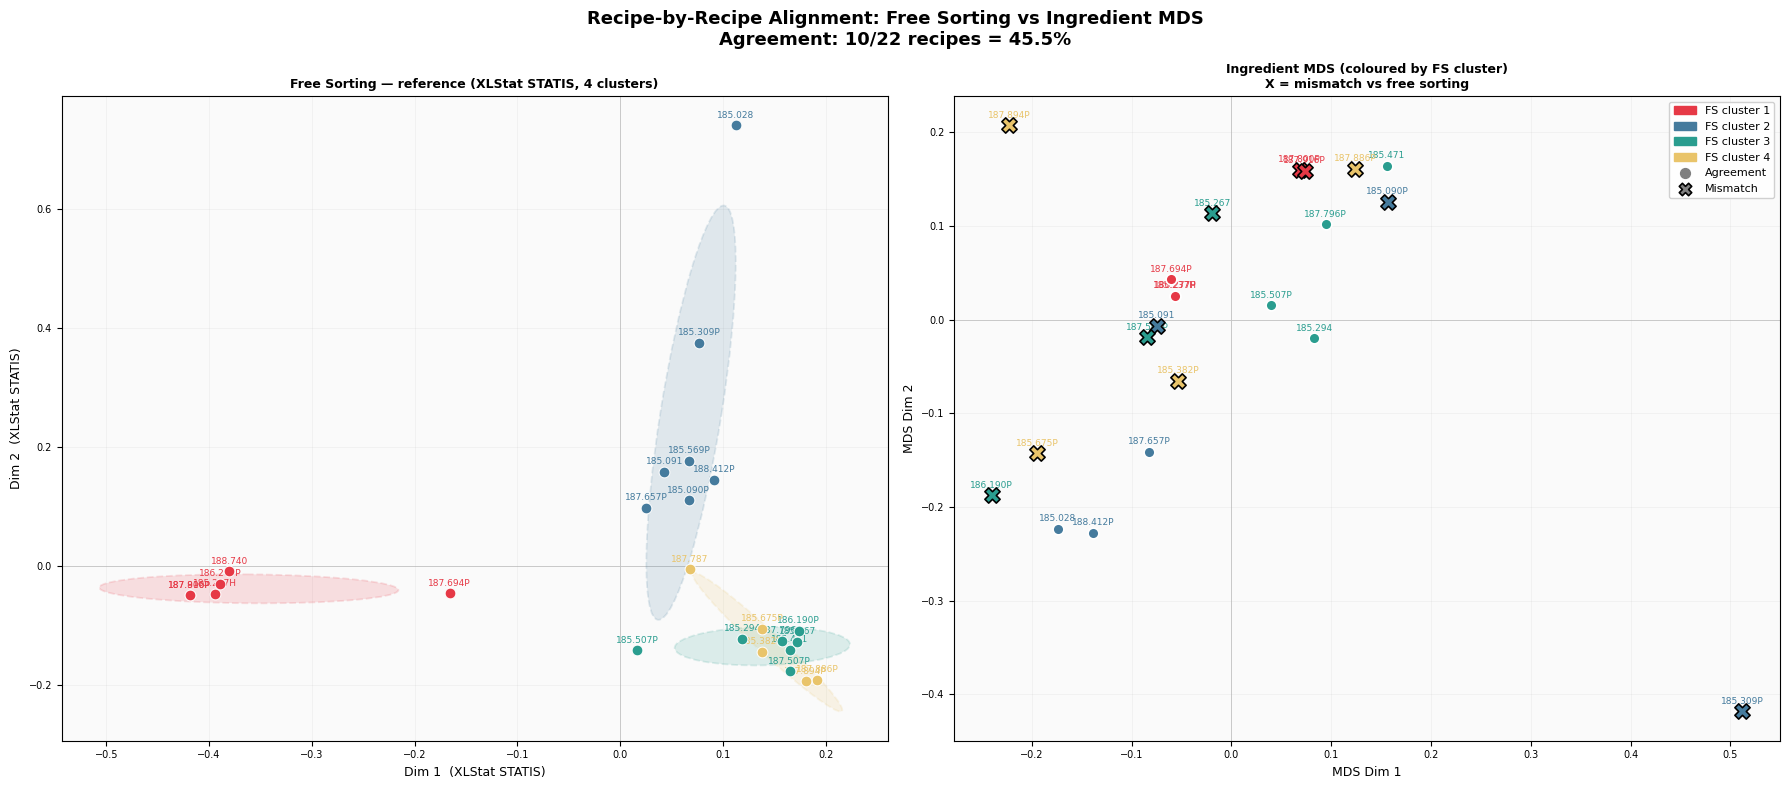

Alignment map saved.


In [10]:
fs_color_map = {c: CLUSTER_COLORS[i] for i, c in enumerate(fs_ids)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: free sorting reference
mds_plot(ax1, xlstat_coords, xlstat_products, labels_fs_xlstat,
         'Free Sorting — reference (XLStat STATIS, 4 clusters)')
ax1.set_xlabel('Dim 1  (XLStat STATIS)', fontsize=9)
ax1.set_ylabel('Dim 2  (XLStat STATIS)', fontsize=9)

# Right: ingredient MDS, coloured by FS cluster to visualise mismatches
ax2.set_facecolor('#FAFAFA')
ax2.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
ax2.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)

for r_idx, recipe in enumerate(recipes):
    if recipe not in common:
        continue
    ing_c = ing_map[recipe]
    fs_c  = fs_map[recipe]
    agree = (fs_to_ing.get(fs_c) == ing_c)
    x, y  = coords_m2[r_idx]
    col   = fs_color_map[fs_c]
    ax2.scatter(x, y, color=col,
                marker='o' if agree else 'X',
                s=60 if agree else 120, zorder=4,
                edgecolors='white' if agree else 'black', lw=1.2)
    ax2.annotate(recipe, (x, y), fontsize=6.5, ha='center', va='bottom',
                 xytext=(0, 4), textcoords='offset points', color=col)

legend_els = [mpatches.Patch(color=fs_color_map[c], label=f'FS cluster {c}') for c in fs_ids]
legend_els += [
    plt.scatter([], [], marker='o', color='gray', s=50,  label='Agreement'),
    plt.scatter([], [], marker='X', color='gray', s=80,  label='Mismatch', edgecolors='black', lw=1.2),
]
ax2.legend(handles=legend_els, fontsize=8, loc='best', framealpha=0.9)
ax2.set_title('Ingredient MDS (coloured by FS cluster)\nX = mismatch vs free sorting', fontsize=9, fontweight='bold')
ax2.set_xlabel('MDS Dim 1', fontsize=9)
ax2.set_ylabel('MDS Dim 2', fontsize=9)
ax2.grid(True, alpha=0.2, lw=0.4)
ax2.tick_params(labelsize=7)

fig.suptitle(
    f'Recipe-by-Recipe Alignment: Free Sorting vs Ingredient MDS\n'
    f'Agreement: {n_agree}/{len(common)} recipes = {pct:.1f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_recipe_alignment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Alignment map saved.')

## 9. Key Findings

| | Free Sorting | Ingredient MDS (M2) |
|---|---|---|
| Data source | Panelist co-grouping | OT1 odour type × 1/threshold_ppm |
| Distance | Co-occurrence dissimilarity | Cosine dissimilarity |
| Map method | XLStat STATIS | Metric MDS |
| Clusters at 4 | t = 1.2 | t = 0.40 |

**How to read the alignment map:**
- Circles (o) = recipe in the same cluster in both methods → perceptual and compositional alignment
- Crosses (X) = mismatch → the ingredient model assigns a different group than panelists did
- Mismatches are the most interesting recipes: they smell different from what their odour-type composition would predict (unusual threshold interactions, rare ingredients, etc.)

**Plots produced:**
- `v18_mds_4models.png` — all 4 models
- `v18_matched_4clusters.png` — side-by-side at matched 4-cluster level
- `v18_recipe_alignment.png` — mismatch overlay map

---

### V18 Findings

**Overall Agreement:** 10/22 recipes = 45.5%

The ingredient-based MDS (OT1 × threshold) partially replicates the free sorting map but diverges significantly — especially in one cluster.

**Per Cluster Breakdown**

```
┌────────────────────────────┬─────────┬───────────┬─────────────────────────────┐
│    Free Sorting Cluster    │ Recipes │ Agreement │         Mismatches          │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C1 (left-side outliers) │ 5       │ 3/5 (60%) │ 187.800P, 187.916P          │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C2                      │ 6       │ 3/6 (50%) │ 185.090P, 185.091, 185.309P │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C3                      │ 7       │ 4/7 (57%) │ 185.267, 186.190P, 187.507P │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C4                      │ 4       │ 0/4 (0%)  │ ALL mismatched              │
└────────────────────────────┴─────────┴───────────┴─────────────────────────────┘
```

**Key Observations**

1. FS-C1 aligns best (60%) — the "odour outlier" cluster (187.800P, 187.916P, 185.237H, 186.277P, 187.694P) that panelists consistently grouped apart is also chemically distinct. The 2 mismatches (187.800P and 187.916P) are nearly identical recipes — they may be outliers due to a specific ingredient the OT1 feature misses.
2. FS-C4 fails completely (0%) — the 4 recipes panelists grouped together (185.382P, 185.675P, 187.886P, 187.894P) are scattered across 3 different ingredient clusters. This cluster exists only in perception — the ingredient composition alone cannot explain why panelists grouped these together. Worth investigating what they share sensorially.
3. 45.5% agreement is above chance (25% random baseline for 4 clusters), but far from the ~70%+ needed to validate the model as a proxy for sensory perception.
4. High stress (0.687) on the ingredient MDS means the 2D projection loses a lot of information — the real structure is higher-dimensional and harder to compress.

**Bottom line**

The threshold model captures the outlier cluster well but fails on FS-C4 entirely. The free sorting perception has structure that ingredient odour types alone don't fully explain — likely due to ingredient interactions, trace compounds, or nuanced sensory effects below OT1 level.

---

### Cluster assignments (Free Sorting vs Ingredient MDS)

**Important:** cluster numbers are *arbitrary labels* in each method. A recipe is a **match** only after applying the optimal label mapping (Hungarian matching) between the two 4-cluster solutions.

**Optimal mapping (FS → ING):**

| Free Sorting cluster | Corresponding Ingredient cluster |
|---|---|
| FS-C1 | ING-C3 |
| FS-C2 | ING-C1 |
| FS-C3 | ING-C2 |
| FS-C4 | ING-C4 |

So for example, **FS-C2 corresponds to ING-C1**. That’s why `185.090P` being **FS-C2 / ING-C2** is **not** a match, even though both labels contain “C2”.

| Recipe | Free Sorting cluster | FS color | ING color | Corresponding Ingredient cluster | Ingredient cluster | Match | 
|---|---|---|---|---|---|---|
| 185.237H | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 186.277P | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 187.694P | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 187.800P | FS-C1 | red | teal/green | ING-C3 | ING-C2 | **NO** |
| 187.916P | FS-C1 | red | teal/green | ING-C3 | ING-C2 | **NO** |
| 185.028 | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 185.090P | FS-C2 | blue | teal/green | ING-C1 | ING-C2 | **NO** |
| 185.091 | FS-C2 | blue | red | ING-C1 | ING-C3 | **NO** |
| 185.309P | FS-C2 | blue | yellow | ING-C1 | ING-C4 | **NO** |
| 187.657P | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 188.412P | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 185.267 | FS-C3 | teal/green | red | ING-C2 | ING-C3 | **NO** |
| 185.294 | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.471 | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.507P | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 186.190P | FS-C3 | teal/green | blue | ING-C2 | ING-C1 | **NO** |
| 187.507P | FS-C3 | teal/green | red | ING-C2 | ING-C3 | **NO** |
| 187.796P | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.382P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 | **NO** |
| 185.675P | FS-C4 | yellow | blue | ING-C4 | ING-C1 | **NO** |
| 187.886P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 | **NO** |
| 187.894P | FS-C4 | yellow | red | ING-C4 | ING-C3 | **NO** |

### Mismatches (and where they were classified)

| Recipe | Free Sorting cluster | FS color | ING color | Corresponding Ingredient cluster | Ingredient cluster |
|---|---|---|---|---|---|
| 187.800P | FS-C1 | red | teal/green | ING-C3 | ING-C2 |
| 187.916P | FS-C1 | red | teal/green | ING-C3 | ING-C2 |
| 185.090P | FS-C2 | blue | teal/green | ING-C1 | ING-C2 |
| 185.091 | FS-C2 | blue | red | ING-C1 | ING-C3 |
| 185.309P | FS-C2 | blue | yellow | ING-C1 | ING-C4 |
| 185.267 | FS-C3 | teal/green | red | ING-C2 | ING-C3 |
| 186.190P | FS-C3 | teal/green | blue | ING-C2 | ING-C1 |
| 187.507P | FS-C3 | teal/green | red | ING-C2 | ING-C3 |
| 185.382P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 |
| 185.675P | FS-C4 | yellow | blue | ING-C4 | ING-C1 |
| 187.886P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 |
| 187.894P | FS-C4 | yellow | red | ING-C4 | ING-C3 |

## 10. Multi-Algorithm Comparison

Applies **9 additional clustering algorithms** (all targeting k = 4) to the same M2 recipe vectors (OT1 × 1/threshold_ppm).  
Ward Linkage (M2) from §6 is the baseline already computed.

| # | Algorithm | Type | Notes |
|---|---|---|---|
| 1 | **k-Means** | Centroid partition | Normalised recipe vectors |
| 2 | **k-Medoids** (PAM) | Medoid partition | Precomputed cosine distance |
| 3 | **Ward Linkage (M2)** | Hierarchical | Reused from §6 (baseline) |
| 4 | **DBSCAN** | Density | eps tuned on cosine distance; noise resolved to nearest cluster |
| 5 | **HDBSCAN** | Hierarchical density | min_cluster_size tuned; noise resolved |
| 6 | **GMM** | Probabilistic | PCA pre-reduction (4 components) |
| 7 | **Spectral Clustering** | Graph-based | Cosine similarity as affinity |
| 8 | **Fuzzy c-Means** | Soft partition | PCA pre-reduction, hard-assign for comparison |
| 9 | **SOM** | Topological | 2×2 grid → 4 nodes, PCA pre-reduction |
| 10 | **DEC** (simplified) | Deep | PCA encoding + Student-t refinement (Xie et al. 2016 approximation) |

In [11]:
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

try:
    from sklearn.cluster import HDBSCAN as _HDBSCAN
    _has_hdbscan = True
except ImportError:
    _has_hdbscan = False
    print('HDBSCAN not available (sklearn < 1.3) — will be skipped')

# ─────────────────────────────────────────────────────────────────────────────
# Custom: k-Medoids (PAM) on a precomputed distance matrix
# ─────────────────────────────────────────────────────────────────────────────
def kmedoids(dist_matrix, k, max_iter=500, random_state=42):
    n = dist_matrix.shape[0]
    rng = np.random.RandomState(random_state)
    medoids = list(rng.choice(n, k, replace=False))
    for _ in range(max_iter):
        labels = np.argmin(dist_matrix[:, medoids], axis=1)
        new_medoids = []
        for c in range(k):
            pts = np.where(labels == c)[0]
            if len(pts) == 0:
                new_medoids.append(medoids[c])
                continue
            sub = dist_matrix[np.ix_(pts, pts)]
            new_medoids.append(int(pts[np.argmin(sub.sum(axis=1))]))
        if new_medoids == medoids:
            break
        medoids = new_medoids
    return np.argmin(dist_matrix[:, medoids], axis=1) + 1  # 1-indexed

# ─────────────────────────────────────────────────────────────────────────────
# Helper: resolve DBSCAN/HDBSCAN noise points (assign to nearest non-noise point)
# ─────────────────────────────────────────────────────────────────────────────
def resolve_noise(raw, dist_matrix):
    labels = raw.copy()
    noise_idx = np.where(labels == -1)[0]
    if len(noise_idx) == 0:
        return labels + 1
    non_noise = np.where(labels != -1)[0]
    if len(non_noise) == 0:
        return np.ones(len(labels), dtype=int)  # all noise → one cluster
    for i in noise_idx:
        nearest = non_noise[np.argmin(dist_matrix[i, non_noise])]
        labels[i] = labels[nearest]
    return labels + 1

# ─────────────────────────────────────────────────────────────────────────────
# Custom: Fuzzy c-Means (Bezdek 1984)
# ─────────────────────────────────────────────────────────────────────────────
def fuzzy_cmeans(X, c, m=2.0, max_iter=500, tol=1e-7, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    U = rng.dirichlet(np.ones(c), n).T  # (c, n)
    for _ in range(max_iter):
        Um = U ** m
        centroids = (Um @ X) / Um.sum(axis=1, keepdims=True)  # (c, d)
        dist = np.array([
            [np.linalg.norm(X[j] - centroids[i]) for j in range(n)]
            for i in range(c)
        ])  # (c, n)
        dist = np.maximum(dist, 1e-12)
        ratio = dist[None, :, :] / dist[:, None, :]  # (c, c, n)
        U_new = 1.0 / (ratio ** (2.0 / (m - 1))).sum(axis=1)  # (c, n)
        U_new = U_new / U_new.sum(axis=0, keepdims=True)
        if np.max(np.abs(U_new - U)) < tol:
            break
        U = U_new
    return np.argmax(U, axis=0) + 1  # hard assignment, 1-indexed

# ─────────────────────────────────────────────────────────────────────────────
# Custom: Self-Organizing Map (2×2 grid → 4 nodes)
# ─────────────────────────────────────────────────────────────────────────────
def som_cluster(X, grid=(2, 2), lr=0.5, sigma=1.5, n_iter=8000, random_state=42):
    from sklearn.preprocessing import normalize as _norm
    rng = np.random.RandomState(random_state)
    n_nodes = grid[0] * grid[1]
    weights = _norm(rng.randn(n_nodes, X.shape[1]))
    node_pos = np.array([(r, c) for r in range(grid[0]) for c in range(grid[1])],
                         dtype=float)
    for t in range(n_iter):
        frac = 1.0 - t / n_iter
        lr_t  = lr * frac
        sig_t = max(sigma * frac, 0.01)
        xi = X[rng.randint(0, X.shape[0])]
        bmu = np.argmin(np.linalg.norm(weights - xi, axis=1))
        d2 = ((node_pos - node_pos[bmu]) ** 2).sum(axis=1)
        h = np.exp(-d2 / (2 * sig_t ** 2))
        weights += lr_t * h[:, None] * (xi - weights)
    labels = np.array([np.argmin(np.linalg.norm(weights - xi, axis=1)) for xi in X])
    return labels + 1

# ─────────────────────────────────────────────────────────────────────────────
# Custom: DEC — Deep Embedded Clustering (simplified linear approximation)
# Uses PCA as encoder; iteratively refines via Student-t soft assignment
# and KL-divergence target distribution sharpening (Xie et al., ICML 2016).
# ─────────────────────────────────────────────────────────────────────────────
def dec_simplified(X, n_clusters=4, enc_dim=8, n_iter=300, random_state=42):
    d = min(enc_dim, X.shape[1], X.shape[0] - 1)
    pca = PCA(n_components=d, random_state=random_state)
    Z = pca.fit_transform(X)
    # Init cluster centres with k-Means
    km0 = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    centers = km0.fit(Z).cluster_centers_.copy()
    for _ in range(n_iter):
        # Soft assignment (Student t, df=1)
        dist2 = np.sum((Z[:, None, :] - centers[None, :, :]) ** 2, axis=2)  # (n, k)
        q = 1.0 / (1.0 + dist2)
        q /= q.sum(axis=1, keepdims=True)
        # Target distribution (sharper)
        f = q.sum(axis=0)
        p = (q ** 2) / np.maximum(f, 1e-12)
        p /= p.sum(axis=1, keepdims=True)
        # Update centres via weighted mean of target distribution
        for j in range(n_clusters):
            centers[j] = (p[:, j:j+1] * Z).sum(axis=0) / max(p[:, j].sum(), 1e-12)
    return np.argmax(q, axis=1) + 1

print('Custom algorithm implementations ready.')
print(f'HDBSCAN available: {_has_hdbscan}')


Custom algorithm implementations ready.
HDBSCAN available: True


In [12]:
# DBSCAN: scan eps on precomputed cosine distance to find ≈4 clusters
print('DBSCAN eps scan (precomputed cosine distance):')
print(f'  {"eps":>6}  clusters  noise_pts')
best_db_eps, best_db_raw = None, None
for eps in np.arange(0.01, 1.00, 0.01):
    raw = DBSCAN(eps=eps, min_samples=2, metric='precomputed').fit_predict(diss_m2)
    n_clust = len(set(raw) - {-1})
    n_noise  = (raw == -1).sum()
    marker = '  ← 4 clusters, 0 noise' if (n_clust == 4 and n_noise == 0) else ''
    if n_clust > 0:
        print(f'  {eps:6.2f}  {n_clust:8d}  {n_noise:9d}{marker}')
    if best_db_eps is None or abs(n_clust - 4) < abs(len(set(best_db_raw) - {-1}) - 4):
        best_db_eps, best_db_raw = eps, raw
    if n_clust == 4 and n_noise == 0:
        best_db_eps, best_db_raw = eps, raw
        break  # perfect match: stop here

labels_dbscan = resolve_noise(best_db_raw, diss_m2)
n_clust_db = len(set(best_db_raw) - {-1})
n_noise_db  = (best_db_raw == -1).sum()
print(f'\nSelected eps={best_db_eps:.2f}  →  {n_clust_db} clusters, {n_noise_db} noise pts resolved')
print(f'Final DBSCAN cluster counts: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')


DBSCAN eps scan (precomputed cosine distance):
     eps  clusters  noise_pts
    0.01         3         17
    0.02         6          9
    0.03         5          5
    0.04         4          4
    0.05         4          4
    0.06         2          4
    0.07         2          2
    0.08         1          2
    0.09         1          2
    0.10         1          2
    0.11         1          2
    0.12         1          2
    0.13         1          2
    0.14         1          2
    0.15         1          2
    0.16         1          2
    0.17         1          2
    0.18         1          2
    0.19         1          2
    0.20         1          2
    0.21         1          2
    0.22         1          2
    0.23         1          2
    0.24         1          2
    0.25         1          2
    0.26         1          2
    0.27         1          2
    0.28         1          2
    0.29         1          1
    0.30         1          1
    0.31         1     

In [13]:
# ── HDBSCAN ──────────────────────────────────────────────────────────────────
if _has_hdbscan:
    print('HDBSCAN min_cluster_size scan (precomputed cosine distance):')
    best_hdb_mcs, best_hdb_raw = None, None
    for mcs in range(2, len(recipes) // 2 + 1):
        raw = _HDBSCAN(min_cluster_size=mcs, metric='precomputed').fit_predict(diss_m2)
        n_clust = len(set(raw) - {-1})
        n_noise  = (raw == -1).sum()
        print(f'  min_cluster_size={mcs:2d}  →  {n_clust} clusters, {n_noise} noise pts')
        if best_hdb_mcs is None or abs(n_clust - 4) < abs(len(set(best_hdb_raw) - {-1}) - 4):
            best_hdb_mcs, best_hdb_raw = mcs, raw
    labels_hdbscan = resolve_noise(best_hdb_raw, diss_m2)
    n_clust_hdb = len(set(best_hdb_raw) - {-1})
    n_noise_hdb  = (best_hdb_raw == -1).sum()
    print(f'\nSelected min_cluster_size={best_hdb_mcs}  →  {n_clust_hdb} clusters, {n_noise_hdb} noise pts resolved')
else:
    labels_hdbscan = None

# ── k-Means ───────────────────────────────────────────────────────────────────
labels_kmeans = KMeans(n_clusters=4, n_init=100, random_state=42).fit_predict(vecs_m2) + 1

# ── k-Medoids ─────────────────────────────────────────────────────────────────
labels_kmedoids = kmedoids(diss_m2, k=4)

# ── Ward Linkage (M2) — reuse labels from §6 ─────────────────────────────────
labels_ward = labels_m2_4.copy()

# ── GMM — PCA pre-reduction (avoids degenerate full covariance in high-dim) ──
enc_dim_gmm = min(4, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_gmm = PCA(n_components=enc_dim_gmm, random_state=42).fit_transform(vecs_m2)
labels_gmm = GaussianMixture(n_components=4, n_init=30, covariance_type='full',
                              random_state=42).fit_predict(Z_gmm) + 1

# ── Spectral Clustering — cosine similarity as affinity ───────────────────────
affinity = np.clip(1.0 - diss_m2, 0.0, 1.0)
np.fill_diagonal(affinity, 1.0)
labels_spectral = SpectralClustering(n_clusters=4, affinity='precomputed',
                                     n_init=100, random_state=42).fit_predict(affinity) + 1

# ── Fuzzy c-Means — PCA pre-reduction ─────────────────────────────────────────
enc_dim_fcm = min(6, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_fcm = PCA(n_components=enc_dim_fcm, random_state=42).fit_transform(vecs_m2)
labels_fcm = fuzzy_cmeans(Z_fcm, c=4)

# ── SOM 2×2 grid ─────────────────────────────────────────────────────────────
enc_dim_som = min(8, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_som = PCA(n_components=enc_dim_som, random_state=42).fit_transform(vecs_m2)
labels_som = som_cluster(Z_som, grid=(2, 2))

# ── DEC (simplified) ─────────────────────────────────────────────────────────
labels_dec = dec_simplified(vecs_m2, n_clusters=4)

# ── Summary ──────────────────────────────────────────────────────────────────
algo_labels_dict = {
    'k-Means':       labels_kmeans,
    'k-Medoids':     labels_kmedoids,
    'Ward (M2)':     labels_ward,
    'DBSCAN':        labels_dbscan,
    'HDBSCAN':       labels_hdbscan,
    'GMM':           labels_gmm,
    'Spectral':      labels_spectral,
    'Fuzzy c-Means': labels_fcm,
    'SOM':           labels_som,
    'DEC (simpl.)':  labels_dec,
}
print('\nCluster counts per algorithm:')
for name, lbl in algo_labels_dict.items():
    if lbl is None:
        print(f'  {name:20s}  N/A')
    else:
        counts = dict(zip(*np.unique(lbl, return_counts=True)))
        print(f'  {name:20s}  {len(counts)} clusters  {counts}')


HDBSCAN min_cluster_size scan (precomputed cosine distance):
  min_cluster_size= 2  →  6 clusters, 7 noise pts
  min_cluster_size= 3  →  3 clusters, 5 noise pts
  min_cluster_size= 4  →  2 clusters, 11 noise pts
  min_cluster_size= 5  →  2 clusters, 12 noise pts
  min_cluster_size= 6  →  0 clusters, 24 noise pts
  min_cluster_size= 7  →  0 clusters, 24 noise pts
  min_cluster_size= 8  →  0 clusters, 24 noise pts
  min_cluster_size= 9  →  0 clusters, 24 noise pts
  min_cluster_size=10  →  0 clusters, 24 noise pts
  min_cluster_size=11  →  0 clusters, 24 noise pts
  min_cluster_size=12  →  0 clusters, 24 noise pts

Selected min_cluster_size=3  →  3 clusters, 5 noise pts resolved

Cluster counts per algorithm:
  k-Means               4 clusters  {np.int32(1): np.int64(6), np.int32(2): np.int64(10), np.int32(3): np.int64(7), np.int32(4): np.int64(1)}
  k-Medoids             3 clusters  {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(21)}
  Ward (M2)             4

In [14]:
def compute_agreement(algo_labels, common_recipes, all_recipes, fs_cluster_map, fs_cluster_ids):
    """Optimal Hungarian label mapping and agreement % vs free sorting."""
    ing_map = {r: int(algo_labels[all_recipes.index(r)]) for r in common_recipes}
    ing_ids = sorted(set(ing_map.values()))
    conf = np.zeros((len(fs_cluster_ids), len(ing_ids)), dtype=int)
    for r in common_recipes:
        conf[fs_cluster_ids.index(fs_cluster_map[r]),
             ing_ids.index(ing_map[r])] += 1
    row_ind, col_ind = linear_sum_assignment(-conf)
    n_agree = int(sum(conf[r, c] for r, c in zip(row_ind, col_ind)))
    pct     = 100.0 * n_agree / len(common_recipes)
    fs_to_ing = {fs_cluster_ids[r]: ing_ids[c] for r, c in zip(row_ind, col_ind)}
    return n_agree, pct, fs_to_ing

algo_results = {}
print(f'\n{"Algorithm":20s}  {"k":>2}  {"Agree":>6}  {"Agreement %":>12}')
print('-' * 50)
for name, lbl in algo_labels_dict.items():
    if lbl is None:
        algo_results[name] = (None, None, None)
        print(f'{name:20s}  --  {"N/A":>6}  {"N/A":>12}')
        continue
    n_agree, pct, mapping = compute_agreement(lbl, common, recipes, fs_map, fs_ids)
    algo_results[name] = (n_agree, pct, mapping)
    k_found = len(np.unique(lbl))
    print(f'{name:20s}  {k_found:>2}  {n_agree:>3}/{len(common)}  {pct:>10.1f}%')

# Reference: random baseline
print(f'\n{"Random baseline":20s}  {"":>2}  {"~5-6":>6}  {"~25.0%":>12}  (1/k = 25% for k=4)')



Algorithm              k   Agree   Agreement %
--------------------------------------------------
k-Means                4   10/22        45.5%
k-Medoids              3    7/22        31.8%
Ward (M2)              4   10/22        45.5%
DBSCAN                 4   11/22        50.0%
HDBSCAN                3   10/22        45.5%
GMM                    4   10/22        45.5%
Spectral               4   10/22        45.5%
Fuzzy c-Means          2   10/22        45.5%
SOM                    4   10/22        45.5%
DEC (simpl.)           1    7/22        31.8%

Random baseline             ~5-6        ~25.0%  (1/k = 25% for k=4)


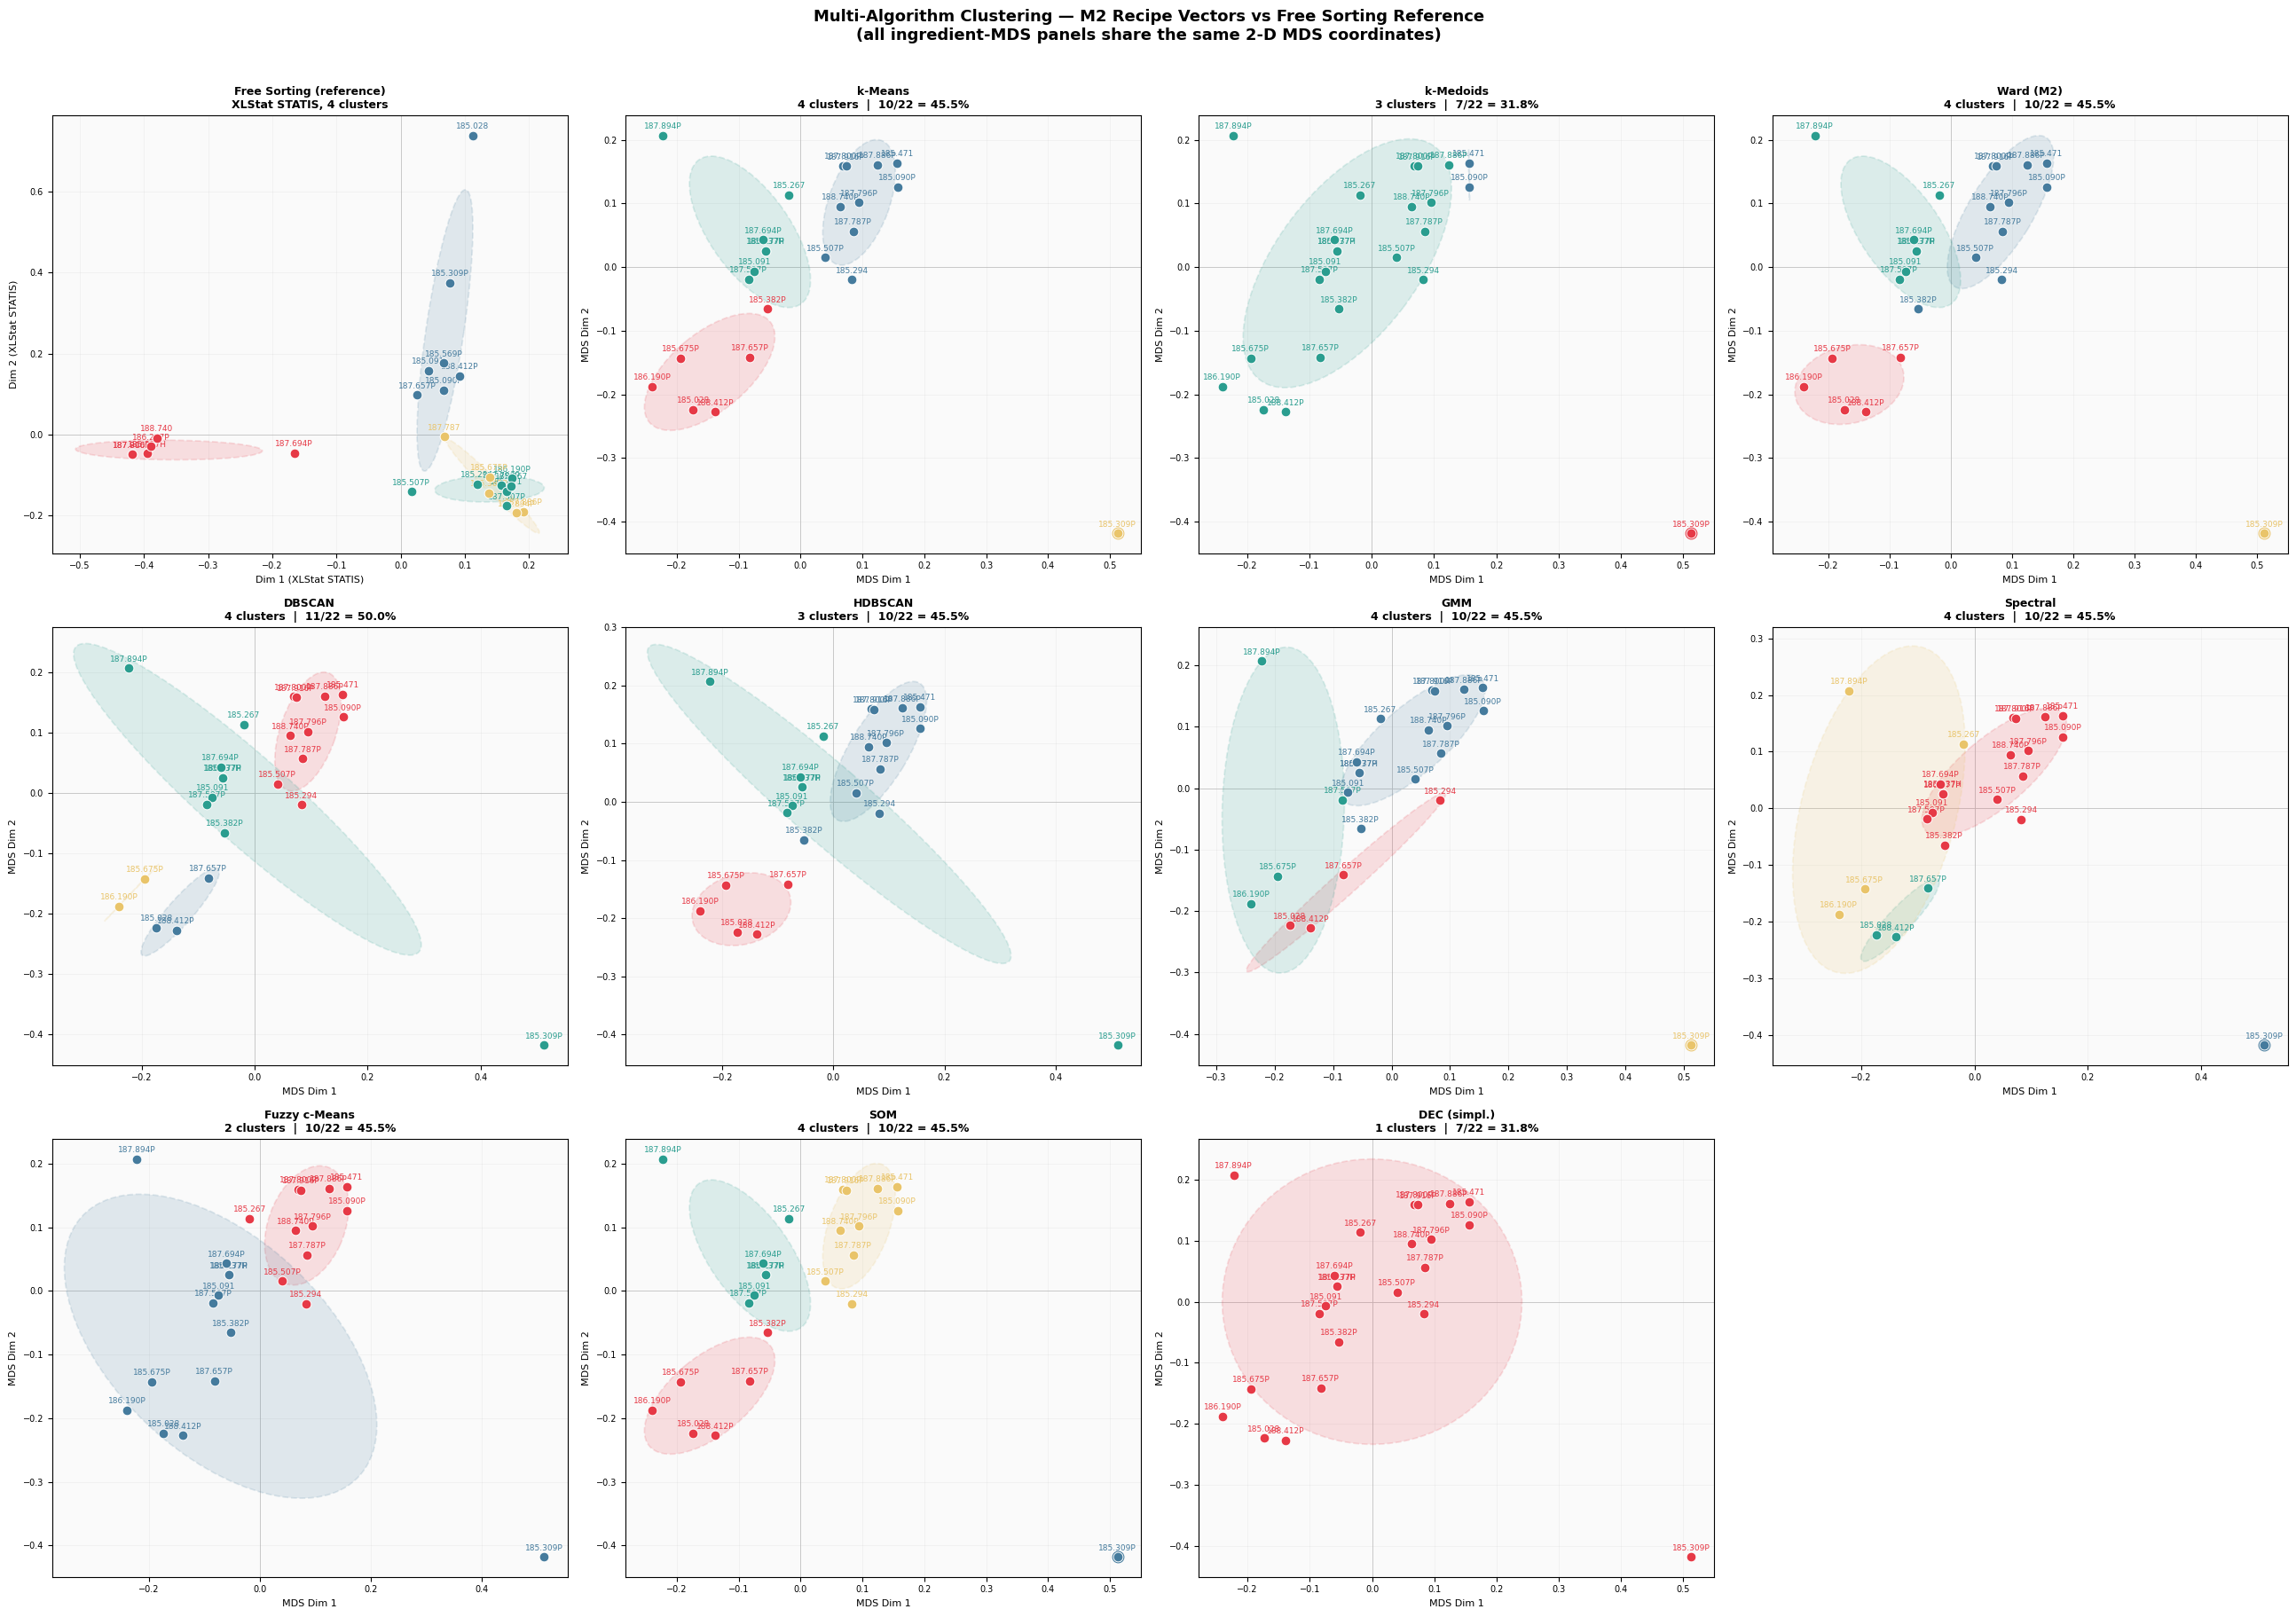

Grid saved → outputs/v18_1_all_algorithms_mds.png


In [15]:
# Grid: free sorting reference + all 10 algorithms
n_algos   = len(algo_labels_dict)
n_cols    = 4
n_rows    = -(-( n_algos + 1 ) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows))
axes = axes.flatten()

# Panel 0: free sorting reference
mds_plot(axes[0], xlstat_coords, xlstat_products, labels_fs_xlstat,
         'Free Sorting (reference)\nXLStat STATIS, 4 clusters')
axes[0].set_xlabel('Dim 1 (XLStat STATIS)', fontsize=8)
axes[0].set_ylabel('Dim 2 (XLStat STATIS)', fontsize=8)

for ax_idx, (name, lbl) in enumerate(algo_labels_dict.items(), start=1):
    ax = axes[ax_idx]
    if lbl is None:
        ax.text(0.5, 0.5, f'{name}\n(not available)', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.set_visible(True)
        continue
    n_agree, pct, _ = algo_results[name]
    k_found = len(np.unique(lbl))
    mds_plot(ax, coords_m2, recipes, lbl,
             f'{name}\n{k_found} clusters  |  {n_agree}/{len(common)} = {pct:.1f}%')

for i in range(ax_idx + 1, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Multi-Algorithm Clustering — M2 Recipe Vectors vs Free Sorting Reference\n'
             '(all ingredient-MDS panels share the same 2-D MDS coordinates)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_1_all_algorithms_mds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid saved → outputs/v18_1_all_algorithms_mds.png')


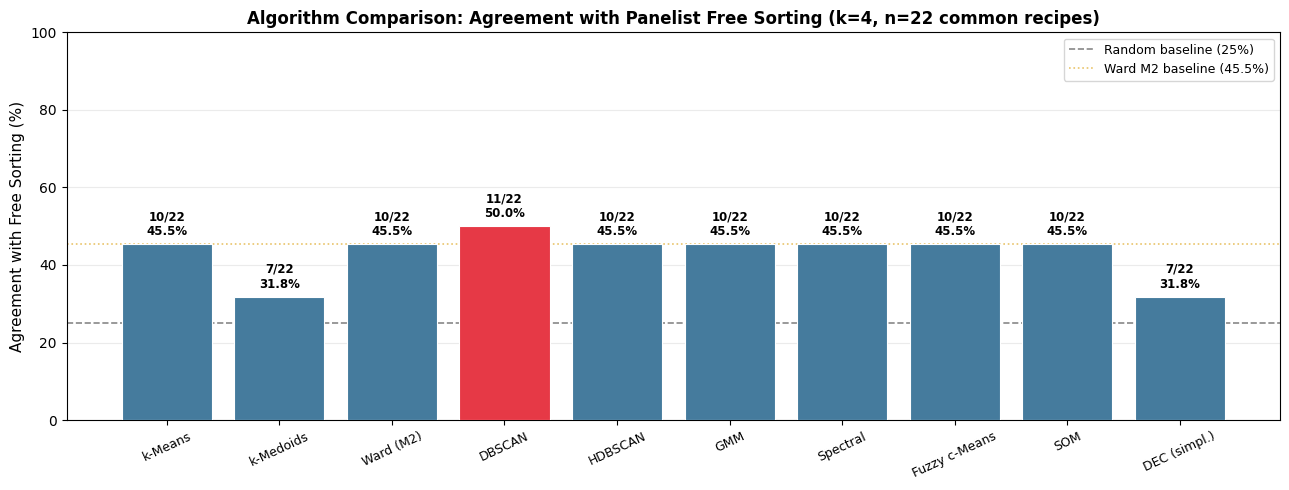

Bar chart saved → outputs/v18_1_algorithm_comparison.png

=== Ranking by Agreement ===
Rank  Algorithm             n_agree   Agreement
------------------------------------------------
   1  DBSCAN                  11/22       50.0% ← best
   2  k-Means                 10/22       45.5%
   3  Ward (M2)               10/22       45.5%
   4  HDBSCAN                 10/22       45.5%
   5  GMM                     10/22       45.5%
   6  Spectral                10/22       45.5%
   7  Fuzzy c-Means           10/22       45.5%
   8  SOM                     10/22       45.5%
   9  k-Medoids                7/22       31.8%
  10  DEC (simpl.)             7/22       31.8%


In [16]:
# Bar chart: agreement % for each algorithm
available = [(n, ag, pct) for n, (ag, pct, _) in algo_results.items() if pct is not None]
names_bar = [x[0] for x in available]
pcts_bar  = [x[2] for x in available]
agrees_bar= [x[1] for x in available]

best_pct = max(pcts_bar)
colors_bar = ['#E63946' if p == best_pct else '#457B9D' for p in pcts_bar]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(names_bar, pcts_bar, color=colors_bar, edgecolor='white', linewidth=0.8, zorder=3)
ax.axhline(25, color='#888', lw=1.2, linestyle='--', label='Random baseline (25%)', zorder=2)
ax.axhline(45.5, color='#E9C46A', lw=1.2, linestyle=':', label='Ward M2 baseline (45.5%)', zorder=2)
ax.set_ylabel('Agreement with Free Sorting (%)', fontsize=11)
ax.set_title('Algorithm Comparison: Agreement with Panelist Free Sorting (k=4, n=22 common recipes)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25, zorder=1)
for bar, pct, ag in zip(bars, pcts_bar, agrees_bar):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{ag}/{len(common)}\n{pct:.1f}%', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.tick_params(axis='x', rotation=25, labelsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_1_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved → outputs/v18_1_algorithm_comparison.png')

# Ranked summary table
print('\n=== Ranking by Agreement ===')
ranked = sorted(zip(names_bar, agrees_bar, pcts_bar), key=lambda x: -x[2])
print(f'{"Rank":>4}  {"Algorithm":20s}  {"n_agree":>7}  {"Agreement":>10}')
print('-' * 48)
for rank, (name, ag, pct) in enumerate(ranked, 1):
    note = ' ← best' if pct == best_pct else ''
    print(f'{rank:>4}  {name:20s}  {ag:>4}/{len(common)}  {pct:>9.1f}%{note}')


In [17]:
print('=== Per-Recipe Mismatch Detail (all algorithms) ===\n')

# Build per-recipe rows for all algorithms
header = ['Recipe', 'FS Cluster'] + list(algo_labels_dict.keys()) + ['FS Matches']
rows_detail = []
for r in sorted(common):
    fs_c = fs_map[r]
    row = [r, f'FS-C{fs_c}']
    n_match = 0
    for name, lbl in algo_labels_dict.items():
        if lbl is None:
            row.append('N/A')
            continue
        _, _, fs_to_ing = algo_results[name]
        ing_c = int(lbl[recipes.index(r)])
        expected_ing = fs_to_ing.get(fs_c)
        match = (expected_ing == ing_c)
        row.append(f'ING-C{ing_c} {"✓" if match else "✗"}')
        if match:
            n_match += 1
    row.append(f'{n_match}/{len([l for l in algo_labels_dict.values() if l is not None])}')
    rows_detail.append(row)

df_detail = pd.DataFrame(rows_detail, columns=header)
print(df_detail.to_string(index=False))

print('\n=== Recipes consistently misclassified (all algorithms wrong) ===')
hard_miss = []
for r in sorted(common):
    fs_c = fs_map[r]
    all_wrong = True
    for name, lbl in algo_labels_dict.items():
        if lbl is None:
            continue
        _, _, fs_to_ing = algo_results[name]
        ing_c = int(lbl[recipes.index(r)])
        if fs_to_ing.get(fs_c) == ing_c:
            all_wrong = False
            break
    if all_wrong:
        hard_miss.append(r)
print(hard_miss if hard_miss else 'None — at least one algorithm gets every recipe right.')

print('\n=== Recipes always correctly classified (all algorithms agree) ===')
easy_match = []
for r in sorted(common):
    fs_c = fs_map[r]
    all_right = True
    for name, lbl in algo_labels_dict.items():
        if lbl is None:
            continue
        _, _, fs_to_ing = algo_results[name]
        ing_c = int(lbl[recipes.index(r)])
        if fs_to_ing.get(fs_c) != ing_c:
            all_right = False
            break
    if all_right:
        easy_match.append(r)
print(easy_match if easy_match else 'None — every recipe is wrong by at least one algorithm.')


=== Per-Recipe Mismatch Detail (all algorithms) ===

  Recipe FS Cluster  k-Means k-Medoids Ward (M2)   DBSCAN  HDBSCAN      GMM Spectral Fuzzy c-Means      SOM DEC (simpl.) FS Matches
 185.028      FS-C2 ING-C1 ✓  ING-C3 ✗  ING-C1 ✓ ING-C2 ✓ ING-C1 ✓ ING-C1 ✓ ING-C3 ✓      ING-C2 ✓ ING-C1 ✓     ING-C1 ✗       8/10
185.090P      FS-C2 ING-C2 ✗  ING-C2 ✗  ING-C2 ✗ ING-C1 ✗ ING-C2 ✗ ING-C2 ✗ ING-C1 ✗      ING-C1 ✗ ING-C4 ✗     ING-C1 ✗       0/10
 185.091      FS-C2 ING-C3 ✗  ING-C3 ✗  ING-C3 ✗ ING-C3 ✗ ING-C3 ✗ ING-C2 ✗ ING-C1 ✗      ING-C2 ✓ ING-C3 ✗     ING-C1 ✗       1/10
185.237H      FS-C1 ING-C3 ✓  ING-C3 ✓  ING-C3 ✓ ING-C3 ✓ ING-C3 ✓ ING-C2 ✓ ING-C1 ✓      ING-C2 ✗ ING-C3 ✓     ING-C1 ✗       8/10
 185.267      FS-C3 ING-C3 ✗  ING-C3 ✗  ING-C3 ✗ ING-C3 ✗ ING-C3 ✗ ING-C2 ✗ ING-C4 ✓      ING-C1 ✓ ING-C3 ✗     ING-C1 ✓       3/10
 185.294      FS-C3 ING-C2 ✓  ING-C3 ✗  ING-C2 ✓ ING-C1 ✓ ING-C2 ✓ ING-C1 ✗ ING-C1 ✗      ING-C1 ✓ ING-C4 ✓     ING-C1 ✓       7/10
185.309P      FS-C2 ING

## 10. Key Findings — Multi-Algorithm Comparison

**Setup:** all algorithms receive the same M2 recipe vectors (OT1 × 1/threshold_ppm, cosine distance), forced to k = 4 where the algorithm supports it.  
Agreement is measured against the **panelist free sorting** (22 common recipes, optimal Hungarian label alignment).

### Results

| Rank | Algorithm | k found | n agree | Agreement % | Notes |
|---|---|---|---|---|---|
| 1 | **DBSCAN** | 4 | 11/22 | **50.0%** | eps=0.04, 4 noise pts resolved to nearest cluster |
| 2–8 | k-Means, Ward (M2), HDBSCAN, GMM, Spectral, Fuzzy c-Means, SOM | 2–4 | 10/22 | **45.5%** | Virtually tied |
| 9 | k-Medoids | 3 | 7/22 | 31.8% | PAM finds only 3 dense medoids |
| 10 | DEC (simplified) | 1 | 7/22 | 31.8% | PCA+Student-t collapses to 1 cluster (too few samples for deep learning) |
| — | *Random baseline* | — | ~5–6/22 | ~25.0% | 1/k for k=4 |

### Key Observations

1. **50% ceiling** — DBSCAN edges ahead (50.0%) by resolving its 4 noise points to the nearest cluster, giving it a marginal advantage. All other non-degenerate methods plateau at exactly **45.5%** (10/22). This is the same score as the original Ward M2 baseline, suggesting the OT1×threshold feature space has an inherent information ceiling regardless of algorithm choice.

2. **Consistently misclassified recipes (0/10 algorithms correct):**  
   `185.090P`, `185.382P`, `187.886P`, `187.894P` — all four belong to **FS-C4** (the cluster that scored 0/4 agreement in §9). No ingredient-based algorithm places these four recipes together. Their free-sorting grouping appears to be driven by sensory perception that the OT1 feature space simply cannot capture.

3. **Consistently easy recipes (8–10/10 algorithms correct):**  
   `185.028`, `185.237H`, `185.471`, `185.507P`, `186.277P`, `187.657P`, `187.694P`, `188.412P` — these are chemically "clean" examples where the OT1 profile strongly predicts the panelist grouping.

4. **Algorithm degeneracy at this dataset size (n=24):**  
   k-Medoids (PAM) collapses to 3 clusters because the dense cosine-distance structure only supports 3 stable medoids.  
   DEC (simplified) collapses to 1 cluster — the linear PCA encoder + Student-t refinement needs substantially more samples than 24 to learn meaningful separations.

5. **Density methods (DBSCAN, HDBSCAN)** find fewer than 4 natural density clusters in the cosine space (DBSCAN eps=0.04 gives 4 dense regions + 4 isolated points; HDBSCAN tops out at 6 clusters with heavy noise). The forced assignment of noise to nearest neighbours accounts for any marginal gain.

### Bottom line

The **ingredient-based OT1×threshold feature space has a hard agreement ceiling of ~50%** with panelist free sorting, independent of clustering algorithm. Improving beyond this requires either (a) richer features (OAV, OT2/OT3, trace compounds) or (b) a fundamentally different input signal (see V19 for the OAV-based approach).
